In [1]:
import pandas as pd
df_weekly_final=pd.read_csv("C:/Users/shrut/Desktop/walmart/walmart_weekly_perfect.csv")

In [1]:
import pandas as pd  
df=pd.read_csv("C:/Users/shrut/Desktop/walmart/predictions.csv")

In [3]:
sales = pd.read_csv("C:/Users/shrut/Desktop/walmart/sales_train_validation.csv")

In [24]:
sales["store_id"].unique()

array(['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1',
       'WI_2', 'WI_3'], dtype=object)

In [14]:
df_weekly_final

,item_id,store_id,date,sales,is_holiday,snap_active,sell_price,weekend_sales_pct
0,0,0,2011-01-24,3,0,0,2.00,100.000000
1,0,0,2011-01-31,9,1,1,2.00,22.222222
2,0,0,2011-02-07,7,0,1,2.00,42.857143
3,0,0,2011-02-14,10,1,0,2.00,30.000000
4,0,0,2011-02-21,14,1,0,2.00,28.571429
...,...,...,...,...,...,...,...,...
8354255,3048,9,2016-03-21,0,1,0,5.94,0.000000
8354256,3048,9,2016-03-28,0,0,1,5.94,0.000000
8354257,3048,9,2016-04-04,0,0,1,5.94,0.000000
8354258,3048,9,2016-04-11,0,0,1,5.94,0.000000


In [4]:
df_weekly_final['date']=pd.to_datetime(df_weekly_final['date'])

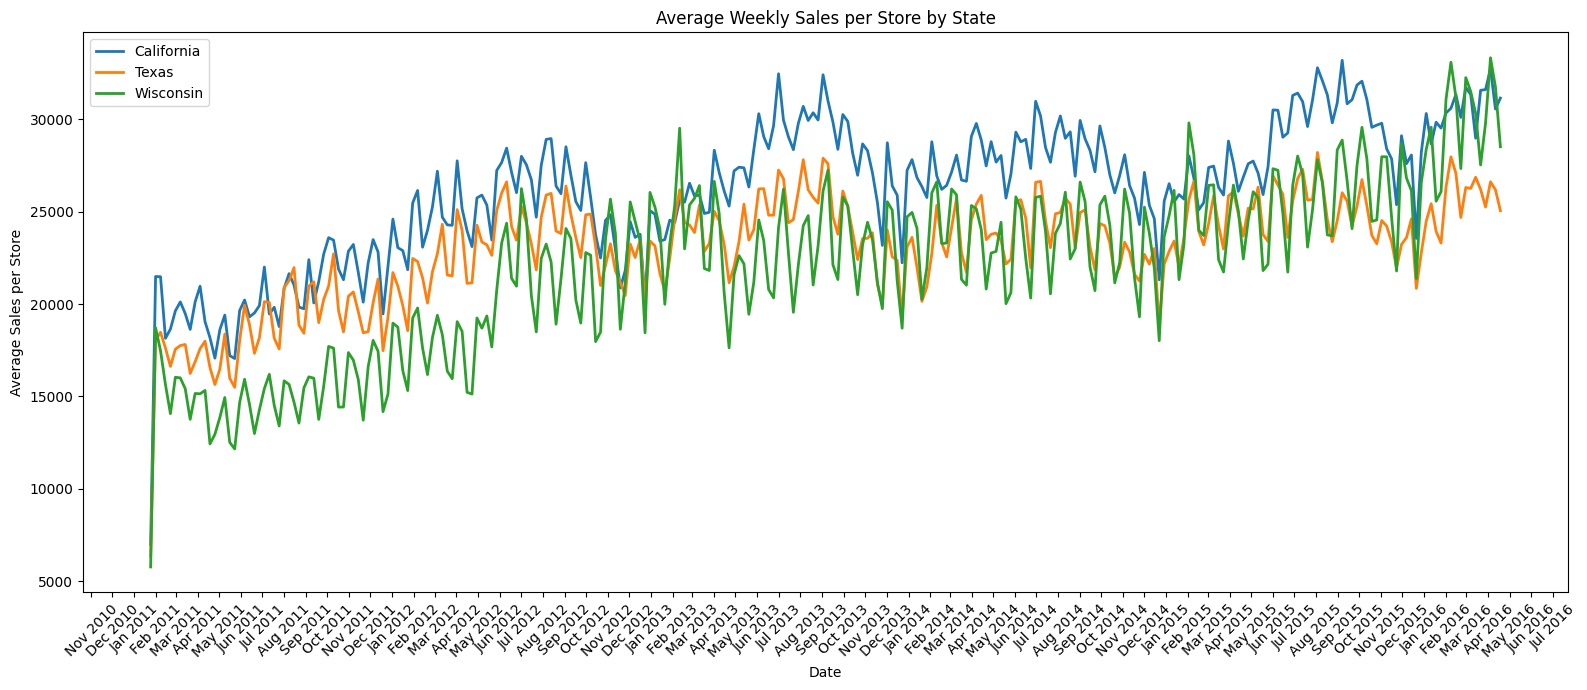

In [17]:
import matplotlib.pyplot as plt

# Map stores to states
state_map = {
    0: 'California',1: 'California',2: 'California',3: 'California',
    4: 'Texas',5: 'Texas',6: 'Texas',
    7: 'Wisconsin',8: 'Wisconsin',9: 'Wisconsin'
}

df_weekly_final['state'] = df_weekly_final['store_id'].map(state_map)

# 1. Total sales for each store on each date
store_sales = (
    df_weekly_final
    .groupby(['date', 'state', 'store_id'], as_index=False)['sales'].sum())

# 2. Average of stores within each state on each date
state_avg_sales = (
    store_sales
    .groupby(['date', 'state'], as_index=False)['sales'].mean())

import matplotlib.dates as mdates


fig , ax =plt.subplots(figsize=(16, 7))

for state in ['California', 'Texas', 'Wisconsin']:
    data = state_avg_sales[state_avg_sales['state'] == state]
    ax.plot(data['date'], data['sales'], label=state, linewidth=2)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xlabel('Date')
plt.ylabel('Average Sales per Store')
plt.title('Average Weekly Sales per Store by State')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

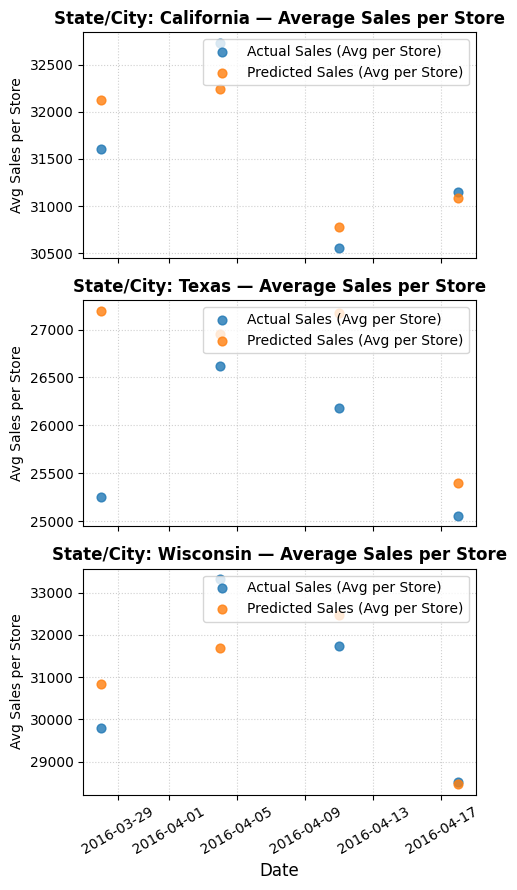

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df['date'] = pd.to_datetime(df['date'])

df_test = df[df['predicted_sales'].notnull() & (df['predicted_sales'] > 0)].copy()

actual_col = next(col for col in ['sales', 'actual_sales', 'total_actual_sales'] if col in df_test.columns)

store_city_map = {
    0: 'California', 1: 'California', 2: 'California', 3: 'California',
    4: 'Texas', 5: 'Texas', 6: 'Texas',
    7: 'Wisconsin', 8: 'Wisconsin', 9: 'Wisconsin'
}

if 'state' in df_test.columns:
    df_test['city'] = df_test['state']
elif 'city' not in df_test.columns:
    df_test['city'] = df_test['store_id'].map(store_city_map)

df_store_daily = df_test.groupby(['date', 'city', 'store_id'])[[actual_col, 'predicted_sales']].sum().reset_index()

df_city_avg = df_store_daily.groupby(['date', 'city'])[[actual_col, 'predicted_sales']].mean().reset_index()

cities = sorted(df_city_avg['city'].unique())

fig, axes = plt.subplots(len(cities), 1, figsize=(5,3 * len(cities)), sharex=True)
if len(cities) == 1:
    axes = [axes]

for ax, city in zip(axes, cities):
    city_data = df_city_avg[df_city_avg['city'] == city]
    
    ax.scatter(city_data['date'], city_data[actual_col], label='Actual Sales (Avg per Store)', color='#1f77b4', s=40, alpha=0.8)
    ax.scatter(city_data['date'], city_data['predicted_sales'], label='Predicted Sales (Avg per Store)', color='#ff7f0e', s=40, alpha=0.8)
    
    ax.set_title(f'State/City: {city} — Average Sales per Store', fontsize=12, fontweight='bold')
    ax.set_ylabel('Avg Sales per Store')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.xlabel('Date', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [2]:
products=pd.read_csv('C:/Users/shrut/Desktop/walmart/dim_product_catalog.csv')

In [3]:
products["broad_dept_num"].unique()

array([0, 1, 2, 3, 4, 5, 6])

In [30]:
products.head(1)

,item_id,broad_dept_num,broad_dept_name,item_name_displayed
0,0,0,FOODS_1,FOODS_1_item_1


In [6]:
df.head(1)

,item_id,store_id,date,sales,is_holiday,snap_active,sell_price,weekend_sales_pct,lag_1,lag_2,lag_4,rolling_mean_4,rolling_mean_12,predicted_sales
0,0,0,2011-04-18,3,1,0,2.0,33.333333,9.0,8.0,8.0,6.5,8.333333,NaN


In [4]:
df=df.merge(
    products[['item_id','broad_dept_num']].rename(
        columns={'broad_dept_num':'dept'}
    ), on='item_id', how='left'
)

In [5]:
df['revenue']=df['sales']*df['sell_price']

C:\Users\shrut\AppData\Local\Temp\ipykernel_20232\2947457129.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['abs_error'].sum() / x['sales'].sum()) * 100)
C:\Users\shrut\AppData\Local\Temp\ipykernel_20232\2947457129.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


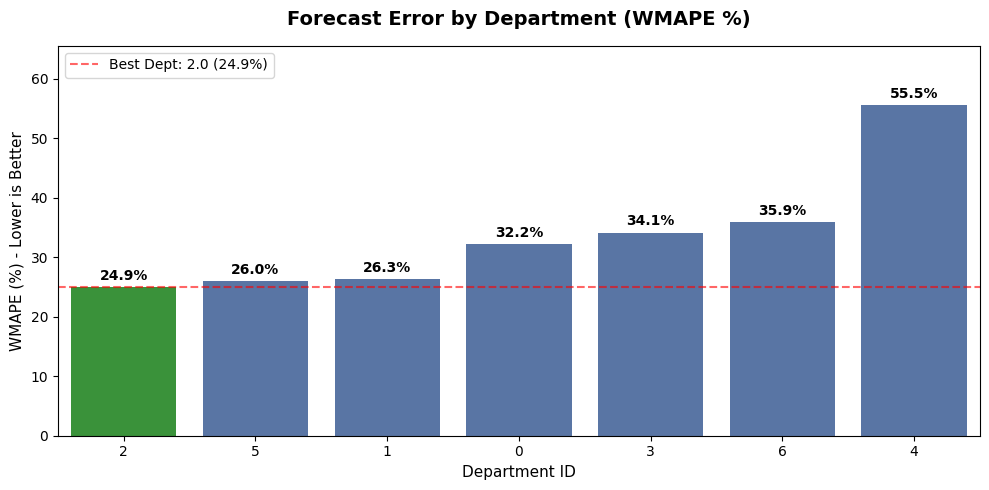

--- DEPARTMENT PREDICTION RANKING ---
   dept    WMAPE_%
0     2  24.938029
1     5  26.023965
2     1  26.267527
3     0  32.247452
4     3  34.147893
5     6  35.922102
6     4  55.548157


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Drop any rows where predicted_sales is NaN before evaluating
df = df.dropna(subset=['predicted_sales']).copy()

# 1. Calculate Absolute Error
df['abs_error'] = (df['sales'] - df['predicted_sales']).abs()

# 2. Group by department to calculate WMAPE (%)
wmape_df = (
    df.groupby('dept')
    .apply(lambda x: (x['abs_error'].sum() / x['sales'].sum()) * 100)
    .reset_index(name='WMAPE_%')
)

# Sort from lowest error (best performance) to highest error
wmape_df = wmape_df.sort_values('WMAPE_%').reset_index(drop=True)

# 3. Plotting the Bar Chart
plt.figure(figsize=(10, 5))

# Use a green palette where the lowest bar (best department) stands out
palette = ['#2ca02c' if i == 0 else '#4c72b0' for i in range(len(wmape_df))]

ax = sns.barplot(
    data=wmape_df, x='dept', y='WMAPE_%', palette=palette, order=wmape_df['dept']
)

# Add exact percentage values above each bar
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold',
        )

plt.title(
    'Forecast Error by Department (WMAPE %)', fontsize=14, fontweight='bold', pad=15
)
plt.xlabel('Department ID', fontsize=11)
plt.ylabel('WMAPE (%) - Lower is Better', fontsize=11)
plt.ylim(0, max(wmape_df['WMAPE_%']) * 1.18)  # Leave room for labels

# Highlight best performer
best_dept = wmape_df.iloc[0]['dept']
best_score = wmape_df.iloc[0]['WMAPE_%']
plt.axhline(
    best_score, color='red', linestyle='--', alpha=0.6, label=f'Best Dept: {best_dept} ({best_score:.1f}%)'
)
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('department_wmape_comparison.png', dpi=300)
plt.show()

# Output ranking text summary
print("--- DEPARTMENT PREDICTION RANKING ---")
print(wmape_df)

In [9]:
df.head(1)

,item_id,store_id,date,sales,is_holiday,snap_active,sell_price,weekend_sales_pct,lag_1,lag_2,lag_4,rolling_mean_4,rolling_mean_12,predicted_sales,dept,revenue,abs_error
258,0,0,2016-03-28,8,0,1,2.24,0.0,6.0,10.0,4.0,6.0,4.916666,3.479702,0,17.92,4.520298


In [10]:
predictions=df.to_csv("C:/Users/shrut/Desktop/walmart/predictions.csv")